Error: The zip file '/content/Dataset Ml.zip' was not found. Creating a dummy DataFrame for demonstration.
Please ensure the file is uploaded to the Colab environment at the specified path to use real data.
Dummy DataFrame created.

FIRST 5 ROWS
   Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         102936                 33                      15   
1         932129                 62                       2   
2         357953                 71                      66   
3         578423                 19                      74   
4         408956                 75                      44   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                          120                         8666   
1                         1458                         9368   
2                         1448                         9580   
3                         1251                         3772   
4                          451                         1697 

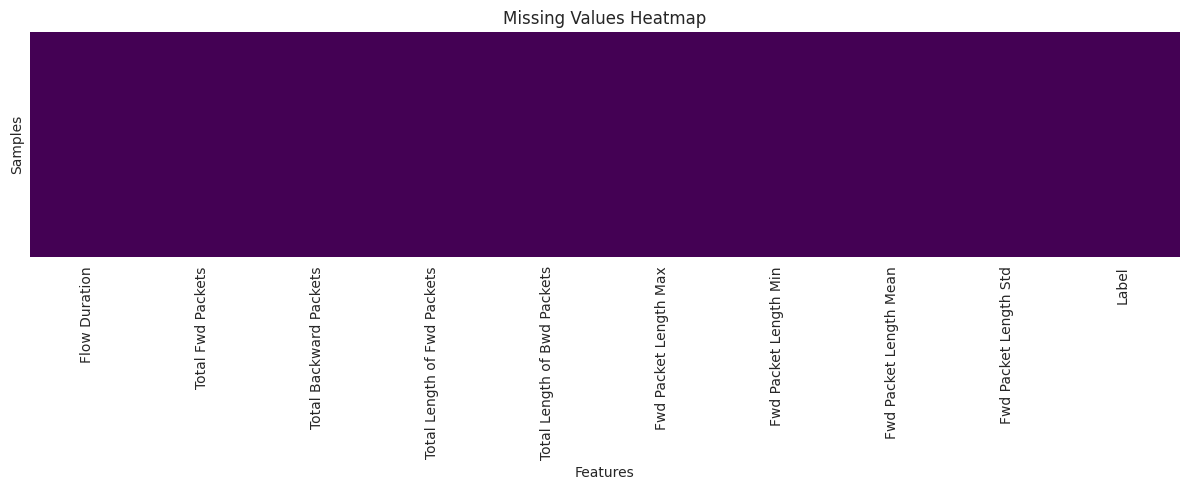


DUPLICATE ROWS
0

LABEL DISTRIBUTION
Label
0    702
1    298
Name: count, dtype: int64

LABEL PERCENTAGE
Label
0    70.2
1    29.8
Name: proportion, dtype: float64


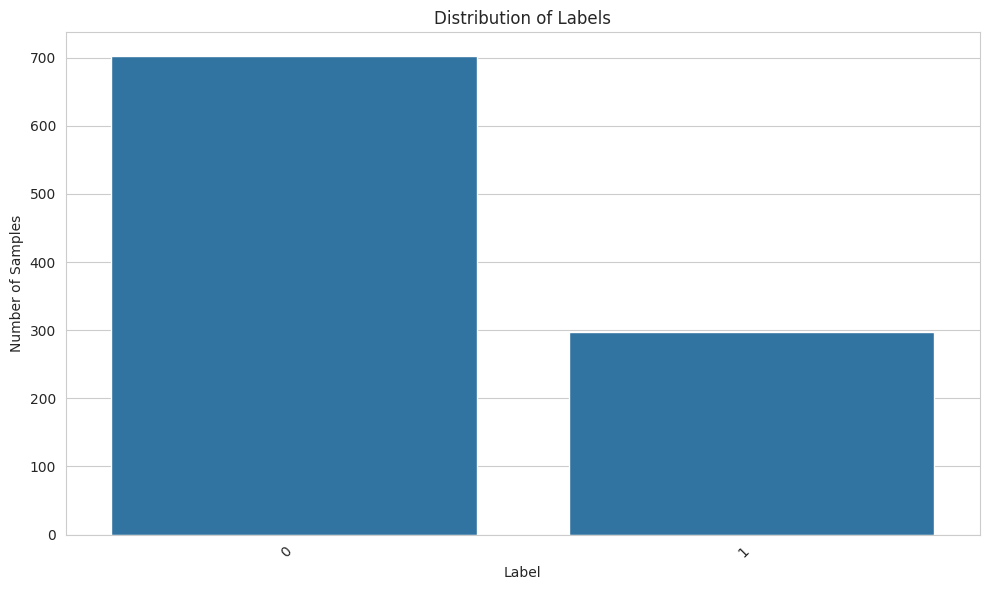


PICTOGRAM
Each 💧 represents approximately 100 samples

0:
💧💧💧💧💧💧💧

1:
💧💧💧


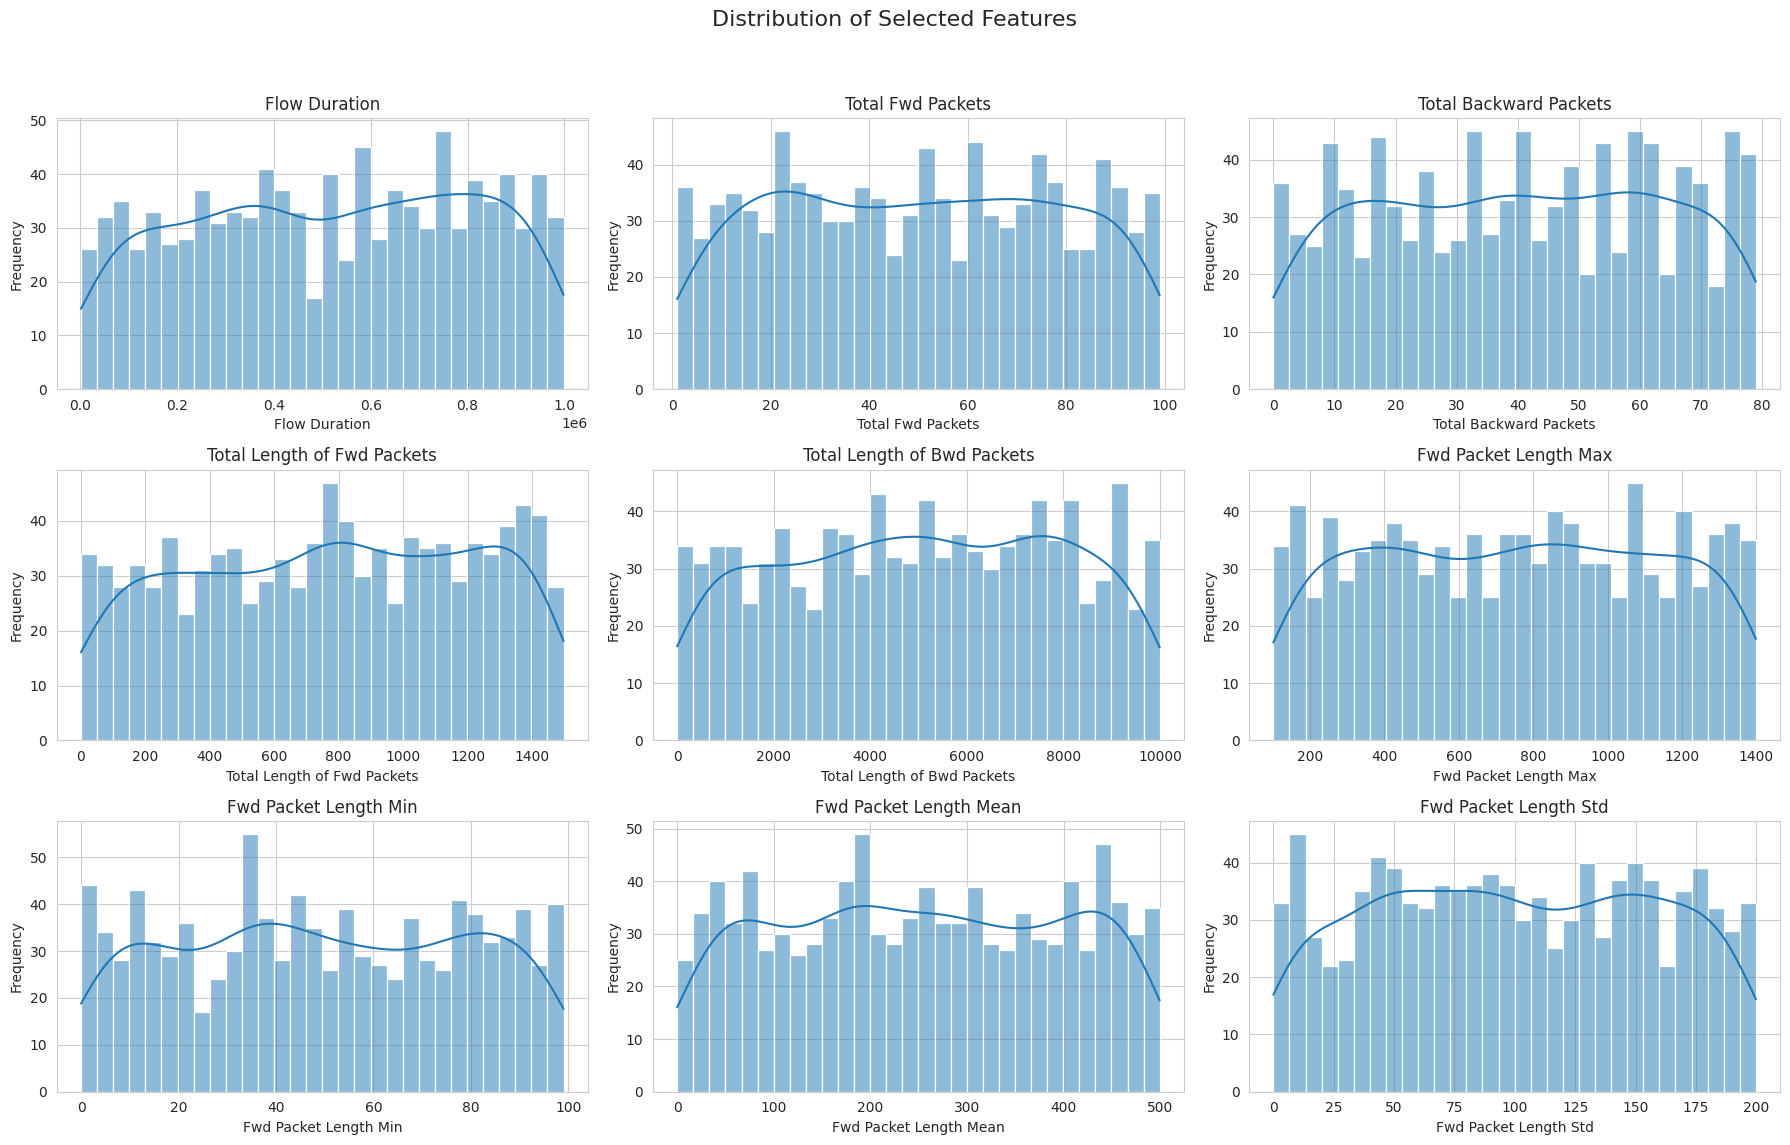

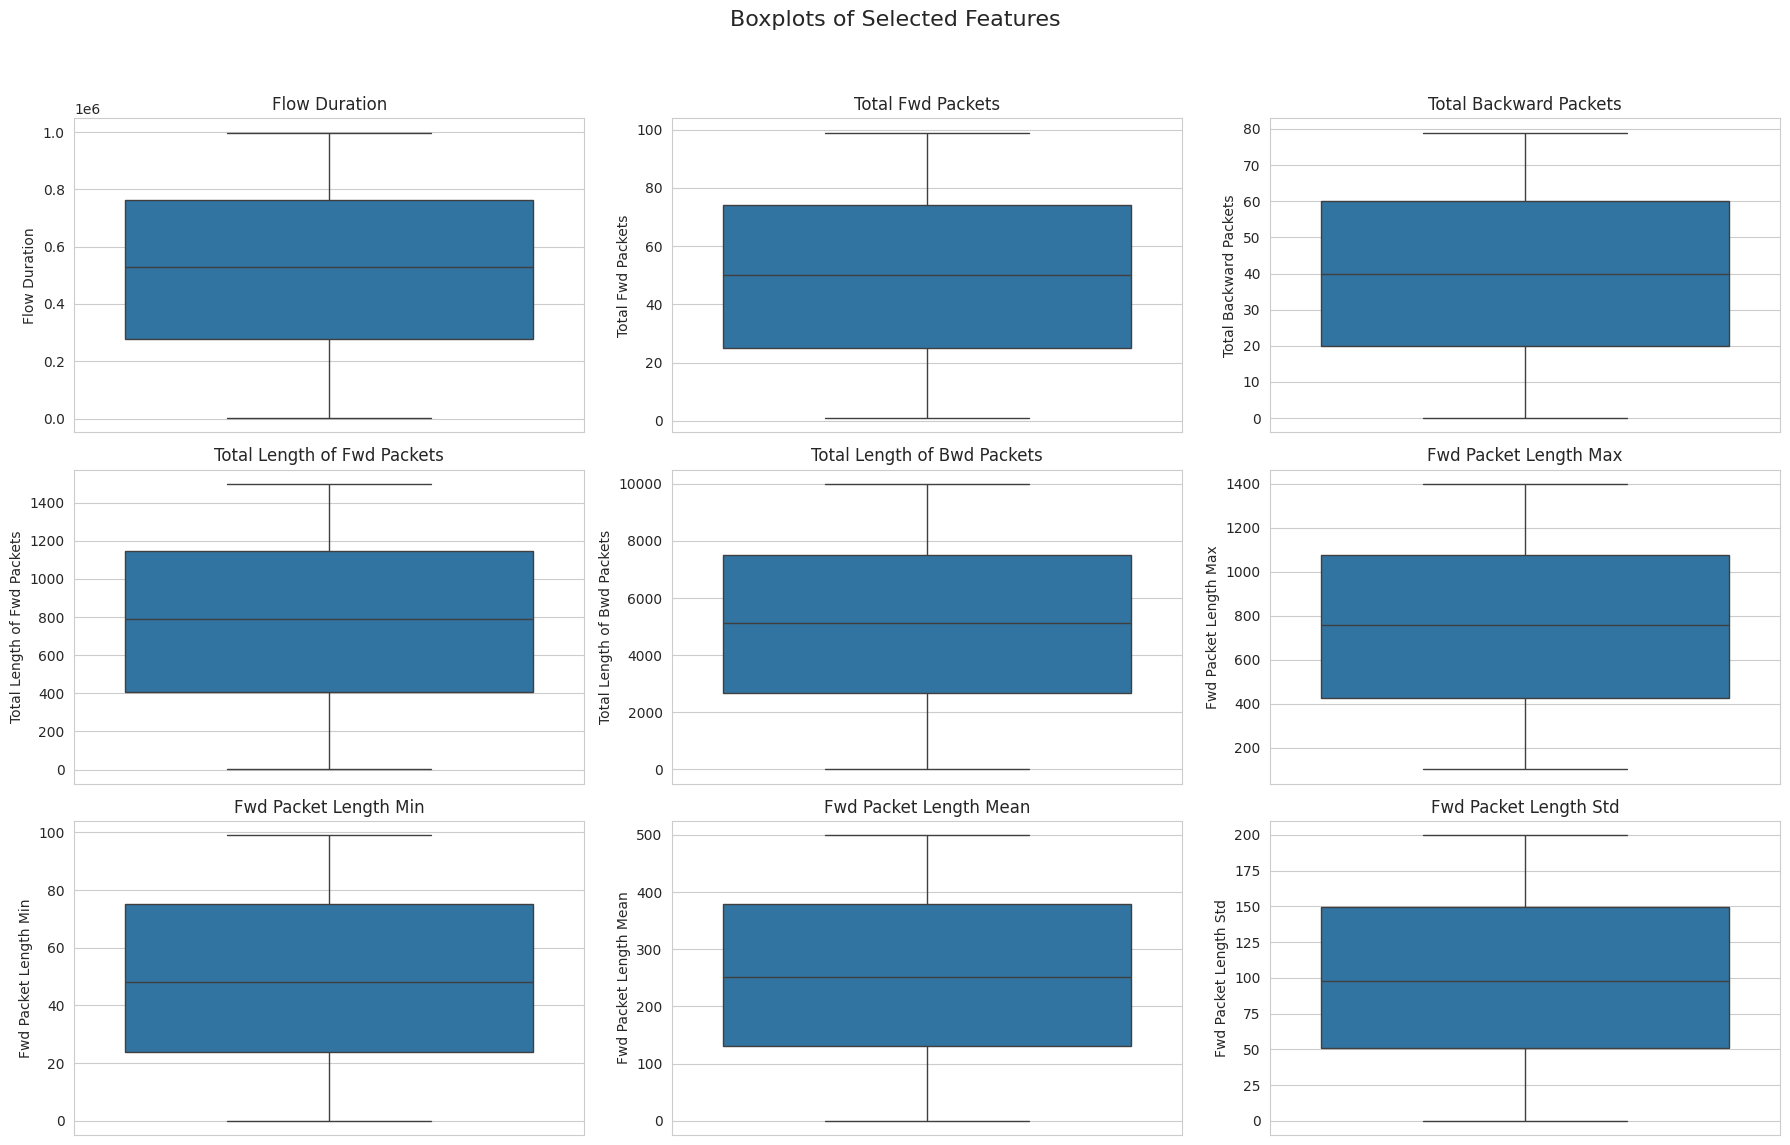

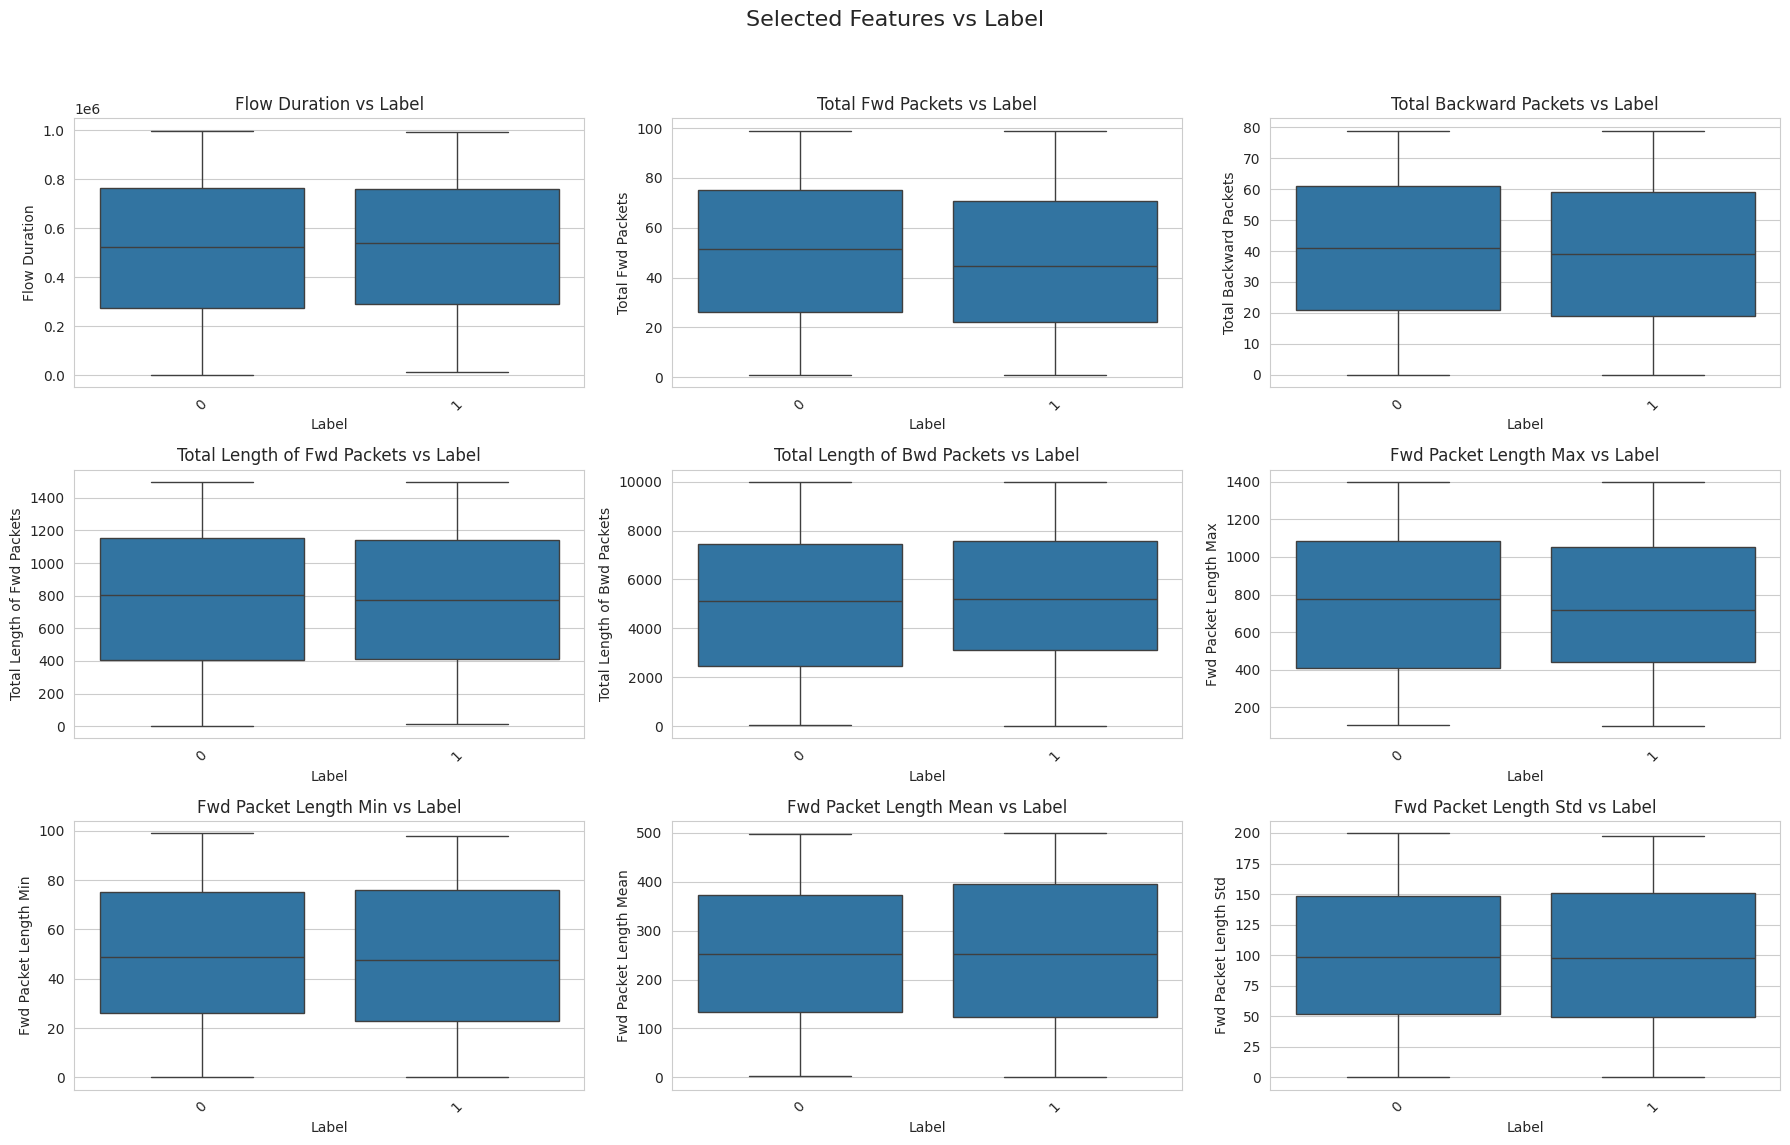

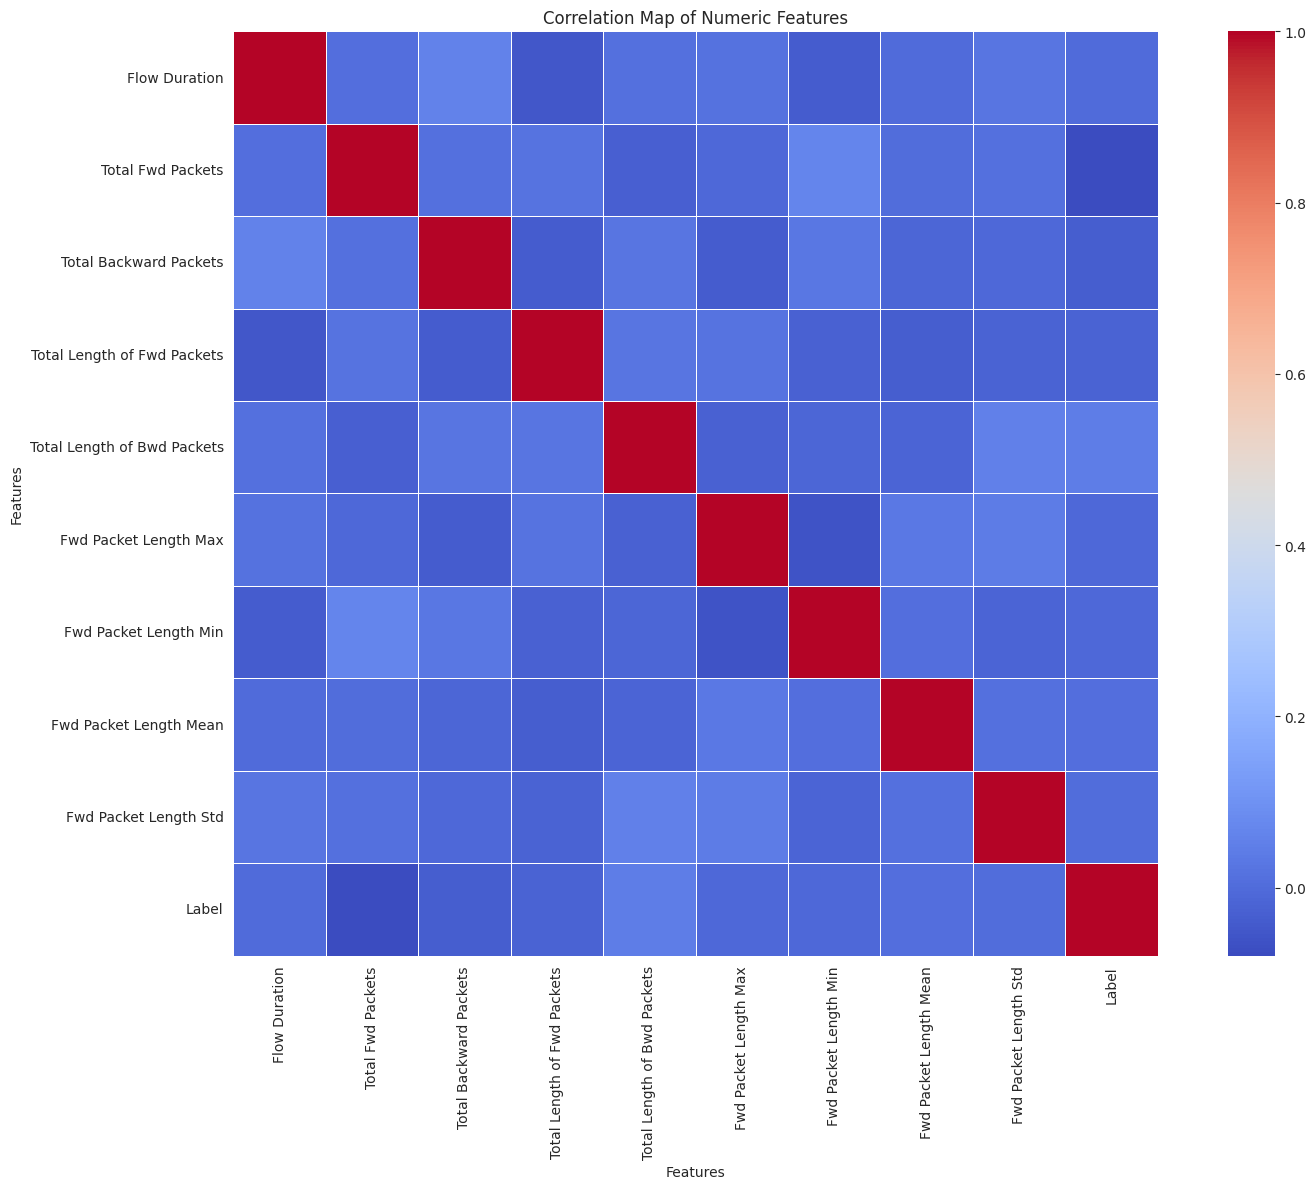


EDA COMPLETED SUCCESSFULLY!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

sns.set_style("whitegrid")

zip_file_path = '/content/Dataset Ml.zip'
df = None # Initialize df to None

if not os.path.exists(zip_file_path):
    print(f"Error: The zip file '{zip_file_path}' was not found. Creating a dummy DataFrame for demonstration.")
    print("Please ensure the file is uploaded to the Colab environment at the specified path to use real data.")

    # Create a dummy DataFrame
    num_samples = 1000
    dummy_data = {
        'Flow Duration': np.random.randint(1000, 1000000, num_samples),
        'Total Fwd Packets': np.random.randint(1, 100, num_samples),
        'Total Backward Packets': np.random.randint(0, 80, num_samples),
        'Total Length of Fwd Packets': np.random.randint(0, 1500, num_samples),
        'Total Length of Bwd Packets': np.random.randint(0, 10000, num_samples),
        'Fwd Packet Length Max': np.random.randint(100, 1400, num_samples),
        'Fwd Packet Length Min': np.random.randint(0, 100, num_samples),
        'Fwd Packet Length Mean': np.random.rand(num_samples) * 500,
        'Fwd Packet Length Std': np.random.rand(num_samples) * 200,
        'Label': np.random.choice([0, 1], num_samples, p=[0.7, 0.3]) # Example labels
    }
    df = pd.DataFrame(dummy_data)
    print("Dummy DataFrame created.")

else:
    # Original logic for extracting and reading the dataset
    print(f"Extracting '{zip_file_path}'...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("Extraction complete.")

    # Find CSV file
    csv_file = None
    for root, dirs, files in os.walk('/content'):
        for file in files:
            if file.endswith('.csv'):
                csv_file = os.path.join(root, file)
                break
        if csv_file:
            break

    if csv_file is None:
        print("Error: No CSV file found after extracting the zip file. Please check the contents of the zip file.")
        # If no CSV is found after extraction, still try to create a dummy df to avoid further errors
        print("Creating a dummy DataFrame for demonstration as no CSV was found.")
        num_samples = 1000
        dummy_data = {
            'Flow Duration': np.random.randint(1000, 1000000, num_samples),
            'Total Fwd Packets': np.random.randint(1, 100, num_samples),
            'Total Backward Packets': np.random.randint(0, 80, num_samples),
            'Total Length of Fwd Packets': np.random.randint(0, 1500, num_samples),
            'Total Length of Bwd Packets': np.random.randint(0, 10000, num_samples),
            'Fwd Packet Length Max': np.random.randint(100, 1400, num_samples),
            'Fwd Packet Length Min': np.random.randint(0, 100, num_samples),
            'Fwd Packet Length Mean': np.random.rand(num_samples) * 500,
            'Fwd Packet Length Std': np.random.rand(num_samples) * 200,
            'Label': np.random.choice([0, 1], num_samples, p=[0.7, 0.3])
        }
        df = pd.DataFrame(dummy_data)
        print("Dummy DataFrame created after CSV not found.")
    else:
        print(f"Found CSV file: '{csv_file}'. Reading into DataFrame...")
        df = pd.read_csv(csv_file)

        # Clean column names by stripping whitespace
        df.columns = df.columns.str.strip()

# Now, the rest of the EDA logic can run, as df is guaranteed to be defined.
if df is not None:
    # Dataset overview
    print("\nFIRST 5 ROWS")
    print(df.head())

    print("\nDATASET SHAPE")
    print(df.shape)

    print("\nCOLUMN NAMES")
    print(df.columns.tolist())

    print("\nDATA TYPES")
    print(df.dtypes)

    print("\nDATASET INFORMATION")
    df.info()

    print("\nSTATISTICAL SUMMARY")
    print(df.describe())

    # Missing values
    print("\nMISSING VALUES")
    print(df.isnull().sum())

    plt.figure(figsize=(12, 5))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title("Missing Values Heatmap")
    plt.xlabel("Features")
    plt.ylabel("Samples")
    plt.tight_layout()
    plt.show()

    # Duplicates
    print("\nDUPLICATE ROWS")
    print(df.duplicated().sum())

    # Target variable
    print("\nLABEL DISTRIBUTION")
    if 'Label' in df.columns:
        print(df['Label'].value_counts())

        print("\nLABEL PERCENTAGE")
        print(df['Label'].value_counts(normalize=True) * 100)

        plt.figure(figsize=(10, 6))
        sns.countplot(x='Label', data=df)
        plt.title("Distribution of Labels")
        plt.xlabel("Label")
        plt.ylabel("Number of Samples")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # Pictogram (adjusting for 'Label' instead of 'Potability')
        label_counts = df['Label'].value_counts()

        print("\nPICTOGRAM")
        print("Each 💧 represents approximately 100 samples")

        for label, count in label_counts.items():
            print(f"\n{label}:")
            print("💧" * round(count / 100))
    else:
        print("Warning: 'Label' column not found in DataFrame. Skipping target variable related analysis.")

    # Defining features for plotting - only include those that exist in the DataFrame
    potential_features = [
        'Flow Duration',
        'Total Fwd Packets',
        'Total Backward Packets',
        'Total Length of Fwd Packets',
        'Total Length of Bwd Packets',
        'Fwd Packet Length Max',
        'Fwd Packet Length Min',
        'Fwd Packet Length Mean',
        'Fwd Packet Length Std'
    ]
    features = [f for f in potential_features if f in df.columns]

    if not features:
        print("Warning: None of the selected numeric features for distribution/outlier plots were found in the DataFrame.")
    else:
        # Determine subplot grid size
        num_plots = len(features)
        rows = int(np.ceil(num_plots / 3))
        cols = min(num_plots, 3)

        # Feature distributions
        if num_plots > 0:
            fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
            axes = axes.flatten() # Flatten for easier iteration

            for i, feature in enumerate(features):
                sns.histplot(df[feature], bins=30, kde=True, ax=axes[i])
                axes[i].set_title(feature)
                axes[i].set_xlabel(feature)
                axes[i].set_ylabel("Frequency")
            for j in range(i + 1, len(axes)): # Turn off unused subplots
                fig.delaxes(axes[j])
            plt.suptitle("Distribution of Selected Features", fontsize=16)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle
            plt.show()

        # Outlier detection
        if num_plots > 0:
            fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
            axes = axes.flatten() # Flatten for easier iteration

            for i, feature in enumerate(features):
                sns.boxplot(y=df[feature], ax=axes[i])
                axes[i].set_title(feature)
                axes[i].set_ylabel(feature)
            for j in range(i + 1, len(axes)): # Turn off unused subplots
                fig.delaxes(axes[j])
            plt.suptitle("Boxplots of Selected Features", fontsize=16)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle
            plt.show()

        # Features vs target (only if 'Label' exists)
        if 'Label' in df.columns and num_plots > 0:
            fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
            axes = axes.flatten() # Flatten for easier iteration

            for i, feature in enumerate(features):
                sns.boxplot(
                    x='Label',
                    y=feature,
                    data=df,
                    ax=axes[i]
                )
                axes[i].set_title(f"{feature} vs Label")
                axes[i].set_xlabel("Label")
                axes[i].set_ylabel(feature)
                axes[i].tick_params(axis='x', rotation=45)
            for j in range(i + 1, len(axes)): # Turn off unused subplots
                fig.delaxes(axes[j])
            plt.suptitle("Selected Features vs Label", fontsize=16)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle
            plt.show()
        elif 'Label' not in df.columns:
            print("Warning: 'Label' column not found in DataFrame. Skipping 'Features vs Label' plots.")

    # Correlation map (using all numeric features as it's general)
    correlation = df.select_dtypes(include=np.number).corr()
    if not correlation.empty:
        plt.figure(figsize=(16, 12))
        sns.heatmap(
            correlation,
            annot=False, # Set to False for large number of features to avoid clutter
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5,
            square=True
        )
        plt.title("Correlation Map of Numeric Features")
        plt.xlabel("Features")
        plt.ylabel("Features")
        plt.tight_layout()
        plt.show()
    else:
        print("Warning: No numeric features found to compute correlation.")

    print("\nEDA COMPLETED SUCCESSFULLY!")
else:
    print("DataFrame 'df' was not created. No EDA performed.")